In [23]:
import polars as pl
import matplotlib.pyplot as plt

In [24]:
df_inicial = pl.read_ods('API_SI.POV.GINI_DS2_en_csv_v2_331189.ods')

Could not determine dtype for column 4, falling back to string
Could not determine dtype for column 5, falling back to string
Could not determine dtype for column 6, falling back to string
Could not determine dtype for column 7, falling back to string
Could not determine dtype for column 8, falling back to string
Could not determine dtype for column 9, falling back to string
Could not determine dtype for column 10, falling back to string
Could not determine dtype for column 11, falling back to string


In [25]:
df_inicial.head()

Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Aruba""","""ABW""","""Gini index""","""SI.POV.GINI""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Africa Eastern and Southern""","""AFE""","""Gini index""","""SI.POV.GINI""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Afghanistan""","""AFG""","""Gini index""","""SI.POV.GINI""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Africa Western and Central""","""AFW""","""Gini index""","""SI.POV.GINI""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""Angola""","""AGO""","""Gini index""","""SI.POV.GINI""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""51.9""",null,null,null,null,null,null,null,"""42.7""",null,null,null,null,null,null,null,null,null,"""51.3""",null,null,null,null,null,null,null


In [26]:
df_inicial['Indicator Name'].unique()

Indicator Name
str
"""Gini index"""


In [27]:
df_brasil = (
    df_inicial.filter(
        pl.col('Country Name') == 'Brazil'
    )
    .unpivot(
        on=[str(ano) for ano in range(1960, 2026)],
        variable_name='ano',
        value_name='valor'
    )
    .filter(
        pl.col('valor').is_not_null()
    )
    .with_columns(
        pl.col('ano').cast(pl.Int64),
        pl.col('valor').cast(pl.Float64)
    )
)

In [28]:
df_brasil.head()

ano,valor
i64,f64
1981,57.9
1982,58.4
1983,58.9
1984,58.3
1985,55.5


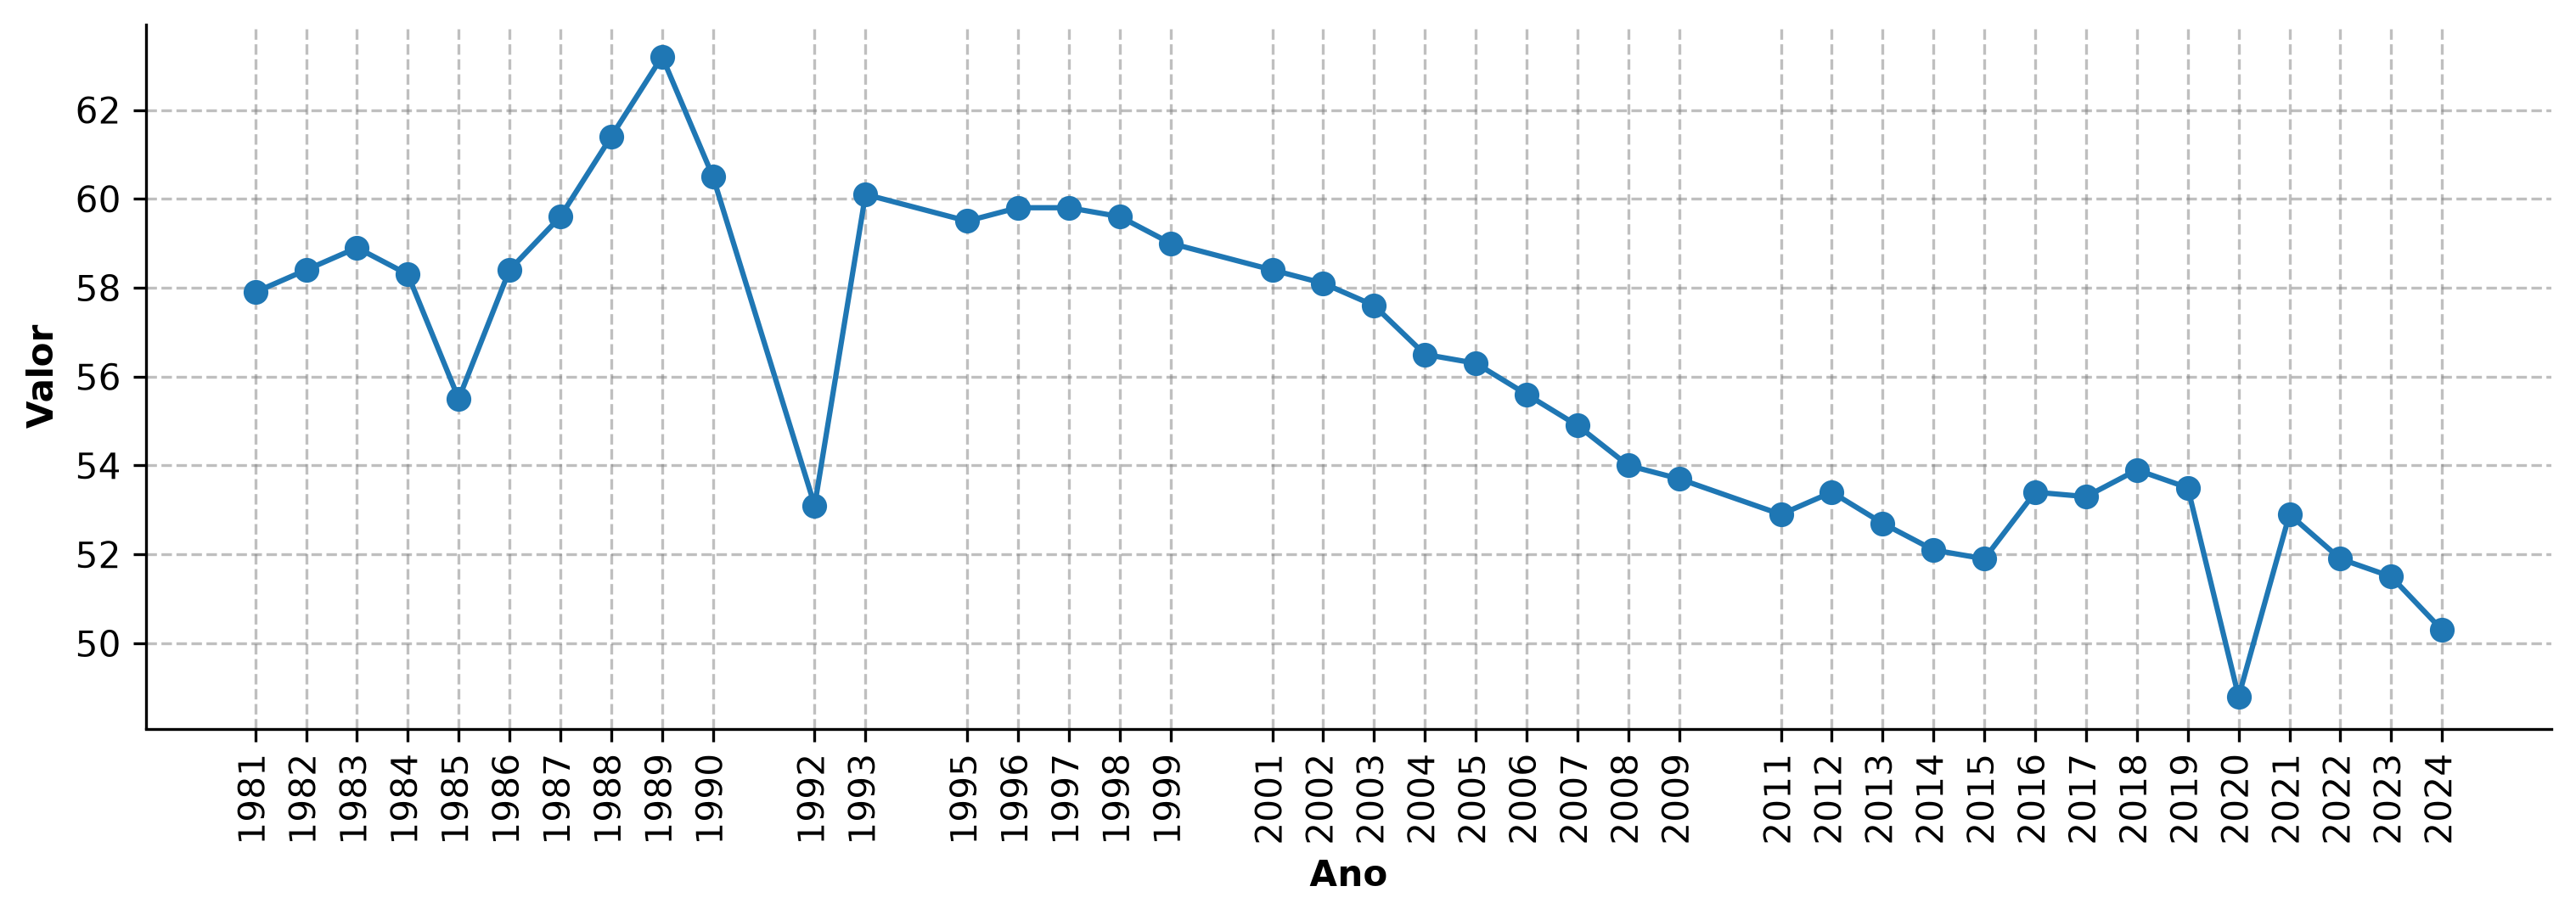

In [30]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

ax.plot(
    df_brasil['ano'],
    df_brasil['valor'],
    marker='o'
)

anos = sorted(df_brasil['ano'].unique().to_list())

ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(anos, labels=anos, rotation=90)
ax.set_ylabel('Valor', fontweight='bold')
ax.set_xlabel('Ano', fontweight='bold')

fig.savefig('gini_wb_brasil', dpi=300, bbox_inches='tight')
plt.show()